# EESC GU4220 Glaciology - Final Project
### Fall 2025
### Instructor: Jonathan Kingslake
### Anna Chen (yc4406)

Outline:
- introduce a variable bed topography to the model
- make SMB a function of elevation instead of x
- get a steady state ice sheet profile, 
- runa simulation where the ELA changes in proportion to an ice core record of temperature 
- extract the elevation change at the divide (H(0,t)) and use it to correct the ice core record for the elevation effect
- re-run the ice sheet model with the corrected temperature record, this will give you a new H(0,t) so you will need to update the ice core again
- repeat these steps until things are not changing between iterations anymore. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Define variable bed topography on Shallow Ice Approximation model and make SMB a function of elevation

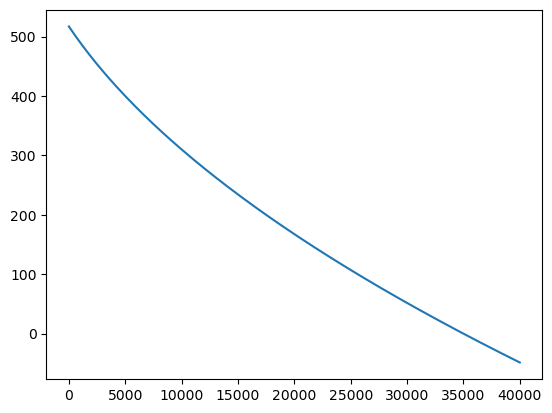

In [12]:
bed_ele = 800
X = 40000
dx = 200

# Space Grid
x = np.linspace(0,X,round(X/dx))    # Space array
Lx = x.size                         # Length of the space array

# Set up sloped bed topography
# Sloped downwards quadratically from ice divide (x=0)
bed = lambda x: bed_ele - bed_ele * ((x+5000)/X)**(0.5)
bed_array = bed(x)
plt.plot(x, bed_array)

In [17]:
def shallow_ice(A = 24*10**(-25) * 365*24*60*60, 
                X = 40000, 
                dx = 200,
                bed_ele = 50,
                T = 6000, 
                dt = 0.004,
                e = 0.0001,
                print_true=False,
                print_period = 80000,
                plot_true=False):
    """ Shallow-ice model with variable parameters, including the flow law parameter A.
    Does not print progress of simulation nor plots by default.

    Parameters:
    -----------------
        A: float
            Flow Law Parameter units [Pa a]
            Original value from Cuffey and Paterson 24e-25, units [Pa s]
        
        X: float
            Maximum length of size the model units [m]
        
        dx: float
            Size of each space step [m]
        
        bed_ele: float
            Elevation of bed at the ice divide [m]
        
        T: float
            Maximum length of time the model is allowed to run, units [year]
        
        dt: float
            Size of each time step [year]

        e: float
            Parameter used to prevent ice thickness from reaching zero
        
        print_true: boolean
            Boolean parameter used to decide whether to report progress of simulation
        
        print_period: float
            When the time reaches a multiple of this number, the progress will be printed
        
        plot_true: boolean
            Boolean parameter used to decide whether to print plots
    
    Returns:
    ----------
        H: 2D numpy array
            2D array with rows being time (Lt) and columns being space (Lx)
        
        x: 1D numpy array
            1D array of space grids
        
        q: 2D numpy array
            2D array with rows being time (Lt) and columns being 1 less than full space grid (Lx-1)
        
        plots if plot_true

    """
    # Space Grid
    x = np.linspace(0,X,round(X/dx))    # Space array
    Lx = x.size                         # Length of the space array

    # Time Grid
    t = np.linspace(0,T,round(T/dt))    # Time array
    Lt = t.size                         # Length of the time array

    # Set up sloped bed topography
    # Sloped downwards from ice divide (when x=0, bed elevation = bed_ele)
    bed = lambda x: bed_ele - bed_ele * ((x+5000)/X)**(0.5)
    bed_array = bed(x)

    # Set up staggered space array
    x_stag = x[0:-1] + dx * 0.5         # Each point in x_stag is the average of the x value before and after it
    Lx_stag = x_stag.size

    # Set up parameters
    n = 3.0                              # The flow law exponent
    rho = 917                            # ice density,  units [kg/m^3]
    g = 10                               # acceleration due to gravity, units [m/s^2]

    # Preallocate the ice thickness array
    H = np.zeros((Lt, Lx))
    H[0, :] = e

    # Define surface mass balance b
    b = lambda x: 10**-4 * (X / 3 - x)       # Recall X is the max spatial length of 40000 m
    b_array = np.asarray(b(x))

    # pre-define flux and coefficients used for flux function
    q = np.zeros((Lt, Lx-1))
    q_coeff = -2.0 * A / (n + 2.0) * (rho * g) ** n

    for timestep in np.arange(1, Lt):
        # only print a message when the remainder of the timestep number and `print_period` is zero.
        if print_true:
            if timestep % print_period == 0:
                print(f'{t[timestep]:.1f} out of {T} years')

        # save the old thickness vector
        H_old = H[timestep - 1, :]

        # (1) compute H on the staggered grid (average of neighboring normal-grid H values)
        H_stag = 0.5 * (H_old[1:] + H_old[:-1])

        # (2) compute surface elevation on the staggered grid
        # bed_stag = 0.5 * (bed_array[1:] + bed_array[:-1])
        surf_old = H_old + bed_array

        # (2) compute the surface slope on the staggered grid
        alpha = (surf_old[1:] - surf_old[:-1]) / dx

        # (3) compute the flux on the staggered grid
        q[timestep, :] = q_coeff * H_stag ** (n + 2.0) * (alpha ** n)

        # (4) compute the ice thickness at the current time step
        dqdx = (q[timestep, 1:] - q[timestep, :-1]) / dx

        H[timestep, 1:-1] = np.maximum(e, H_old[1:-1] + dt * (b_array[1:-1] - dqdx))

        # enforce minimum thickness and boundary conditions
        H[timestep, 0] = H[timestep, 1]
        H[timestep, -1] = e
    
    if plot_true:
        # Plot results
        fig = plt.figure(figsize=(12,8))

        axes = fig.add_subplot(4,1,1)
        axes.plot(x, H[-1, :], 'g-')
        axes.set_xlabel('distance, $x$ [m]')
        axes.set_ylabel('final ice thickness, $H(x,T)$')
        axes.set_title('Final Ice Thickness H(-1, :)')

        axes = fig.add_subplot(4,1,2)
        axes.plot(x, np.transpose(H[0:-1:10000, :]))
        axes.set_xlabel(r'distance, $x$ [m]')
        axes.set_ylabel(r'ice thickness, $H(x,T)$')
        axes.set_title('Ice Thickness at each 10,000th time step')

        axes = fig.add_subplot(4,1,3)
        axes.plot(t, H[:, 0], 'g-')
        axes.set_xlabel(r'time, $t$ [years]')
        axes.set_ylabel('ice thickness [m]')
        axes.set_title('Ice Thickness at the left of the domain, $H(x=0,t)$')

        axes = fig.add_subplot(4,1,4)
        axes.plot(x[0:-1], q[-1, :], 'g-')
        axes.set_xlabel('Distance, $x$ [m]')
        axes.set_ylabel('Ice flux, $q(x,T)$ [m^2/s]')
        axes.set_title('Final Ice Flux, $q(x,T=-1)$')

        plt.show()
    
    return H, x, q

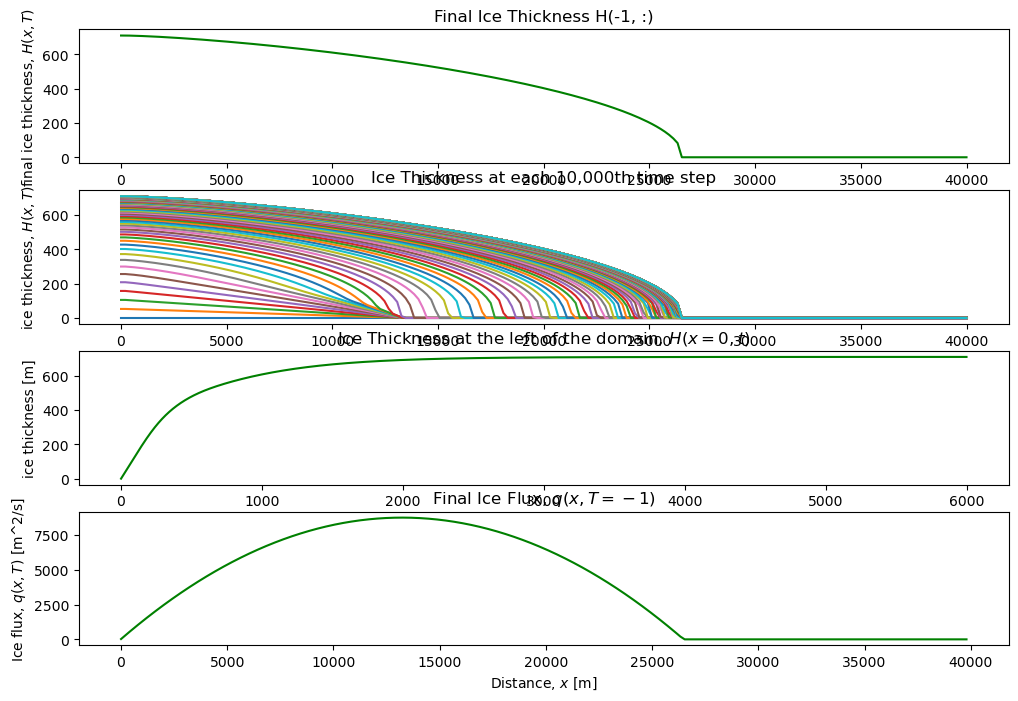

(array([[1.00000000e-04, 1.00000000e-04, 1.00000000e-04, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04],
        [5.35293132e-03, 5.35293132e-03, 5.27252931e-03, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04],
        [1.06058626e-02, 1.06058626e-02, 1.04450586e-02, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04],
        ...,
        [7.08498190e+02, 7.08498190e+02, 7.08024638e+02, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04],
        [7.08498190e+02, 7.08498190e+02, 7.08024638e+02, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04],
        [7.08498190e+02, 7.08498190e+02, 7.08024638e+02, ...,
         1.00000000e-04, 1.00000000e-04, 1.00000000e-04]]),
 array([    0.        ,   201.00502513,   402.01005025,   603.01507538,
          804.0201005 ,  1005.02512563,  1206.03015075,  1407.03517588,
         1608.04020101,  1809.04522613,  2010.05025126,  2211.05527638,
         2412.06030151,  2613.06532663,  2814.070

In [18]:
shallow_ice(plot_true=True)

### 2. Load Antarctica surface ice velocity data

In [8]:
data = np.load('P6_data.npz')

u = data['u']
v = data['v']
x_velocity = data['x_velocity']
y_velocity = data['y_velocity']

bed_elevation = data['bed_elevation']
surface_elevation = data['surface_elevation']
surface_slope = data['surface_slope']
ice_thickness = data['ice_thickness']
x_bedmap = data['x_bedmap']
y_bedmap = data['y_bedmap']

print(f"shape of x_velocity is {x_velocity.shape}")
print(f"shape of u is {u.shape}")
print(f"shape of y_velocity is {y_velocity.shape}")
print(f"shape of v is {v.shape}")

shape of x_velocity is (1160,)
shape of u is (1120, 1160)
shape of y_velocity is (1120,)
shape of v is (1120, 1160)
